In [ ]:
from pathlib import Path
import xarray as xr
import matplotlib.pyplot as plt


# TODO -> Add this as test data + show the same plots


xds_path = Path("../sample-data/hs-issue-0117.nc")

if xds_path.exists():
    hs = xr.load_dataset(xds_path)["hs"]
else:
    ds = xr.open_dataset(
        "https://thredds.met.no/thredds/dodsC/windsurfer/mywavewam3km_files/2023/10/20231028_MyWam3km_hindcast.nc"
    )
    hs = ds.isel(
        rlat=slice(200, 500),
        rlon=slice(2000, 2250),
    )["hs"].load()

    # Persist to sample-data directory for testing with the extension
    hs.to_netcdf(xds_path)

hs

<xarray.DataArray 'hs' (time: 24, rlat: 300, rlon: 250)> Size: 7MB
array([[[1.5090202 , 1.4911155 , 1.4727348 , ...,        nan,
                nan,        nan],
        [1.4667344 , 1.4531028 , 1.4385378 , ...,        nan,
                nan,        nan],
        [1.4264984 , 1.4160058 , 1.4040271 , ...,        nan,
                nan,        nan],
        ...,
        [1.0665075 , 1.0481062 , 1.0263186 , ...,        nan,
                nan,        nan],
        [1.0621718 , 1.0408708 , 1.0158409 , ...,        nan,
                nan,        nan],
        [1.0556338 , 1.0300616 , 1.0012022 , ...,        nan,
                nan,        nan]],

       [[1.7707804 , 1.743689  , 1.7003202 , ...,        nan,
                nan,        nan],
        [1.727431  , 1.7020875 , 1.664938  , ...,        nan,
                nan,        nan],
        [1.6766249 , 1.6510041 , 1.6180059 , ...,        nan,
                nan,        nan],
...
        [0.9919579 , 0.97303414, 0.95382136, ...,        nan,
                nan,        nan],
        [0.97911763, 0.95910364, 0.9380435 , ...,        nan,
                nan,        nan],
        [0.96607953, 0.9443786 , 0.9215826 , ...,        nan,
                nan,        nan]],

       [[1.8234597 , 1.8293122 , 1.834937  , ...,        nan,
                nan,        nan],
        [1.82448   , 1.8278146 , 1.8342748 , ...,        nan,
                nan,        nan],
        [1.8115889 , 1.8126917 , 1.8203484 , ...,        nan,
                nan,        nan],
        ...,
        [0.9853606 , 0.9660544 , 0.94542986, ...,        nan,
                nan,        nan],
        [0.97148234, 0.95122147, 0.92886597, ...,        nan,
                nan,        nan],
        [0.95738775, 0.93536806, 0.9118025 , ...,        nan,
                nan,        nan]]], shape=(24, 300, 250), dtype=float32)
Coordinates:
  * rlat     (rlat) float32 1kB -5.7 -5.67 -5.64 -5.61 ... 3.18 3.21 3.24 3.27
  * rlon     (rlon) float32 1kB 19.6 19.63 19.66 19.69 ... 27.01 27.04 27.07
  * time     (time) datetime64[ns] 192B 2023-10-28 ... 2023-10-28T23:00:00
Attributes:
    long_name:      Total significant wave height
    standard_name:  sea_surface_wave_significant_height
    units:          m
    grid_mapping:   projection_ob_tran
    _ChunkSizes:    [   1   36 2379]

### histogram of all values

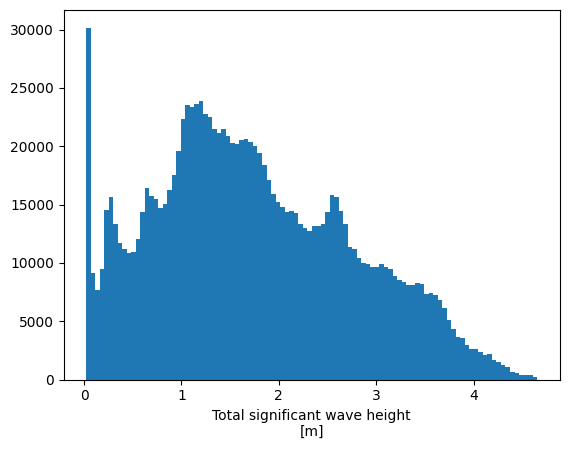

In [7]:
plt.figure()
hs.plot(bins=100)
plt.show()

### histogram selected data

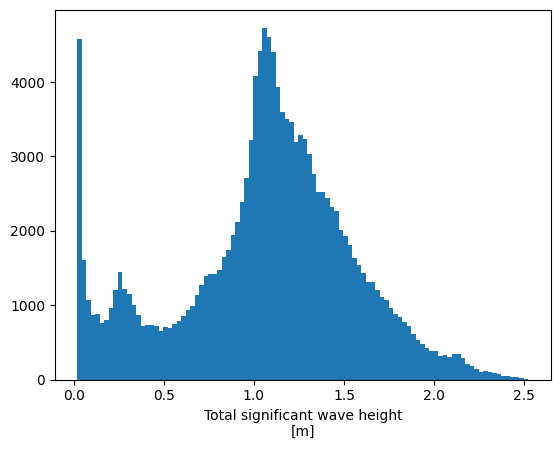

In [8]:
plt.figure()
hs.isel(
    time=slice(0, 12),
    rlat=slice(0, 100),
).plot(bins=100)
plt.show()


### map single timestamp

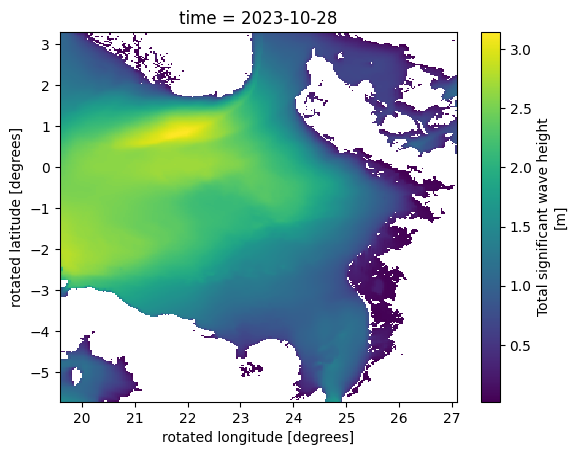

In [9]:
plt.figure()
hs.isel(time=0).plot()  # map single timestamp
plt.show()


### timeseries single point

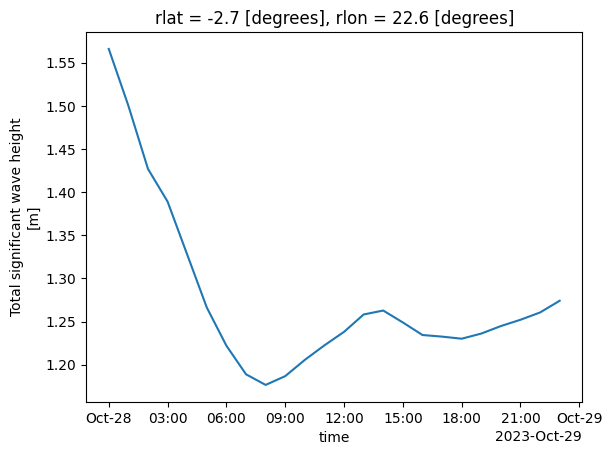

In [10]:
plt.figure()
hs.isel(rlat=100, rlon=100).plot()
plt.show()

## 4 maps, 6h interval

<Figure size 640x480 with 0 Axes>

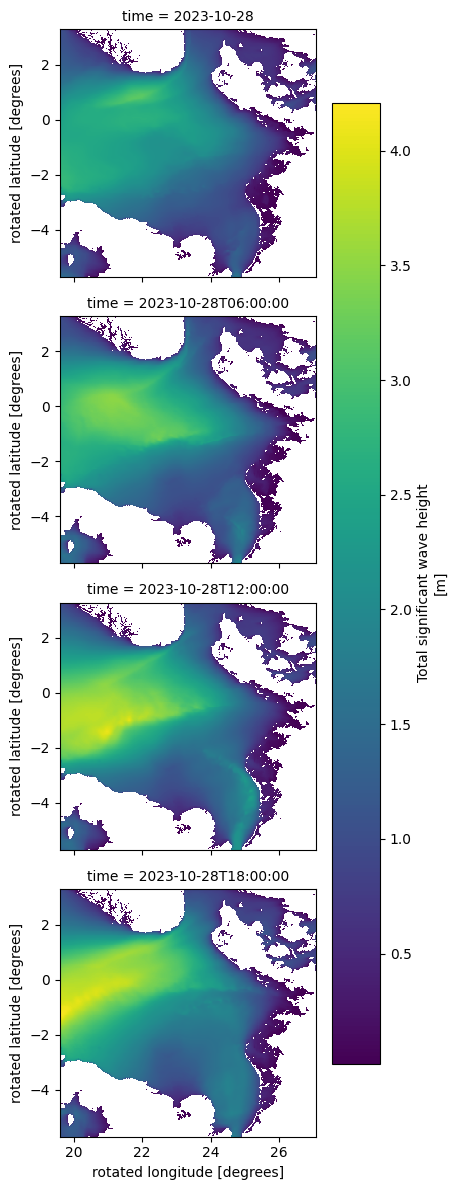

In [11]:
plt.figure()
hs.isel(time=slice(0, 24, 6)).plot(row="time")  # 4 maps, 6h interval


## 5x5 faceted timeseries

<Figure size 640x480 with 0 Axes>

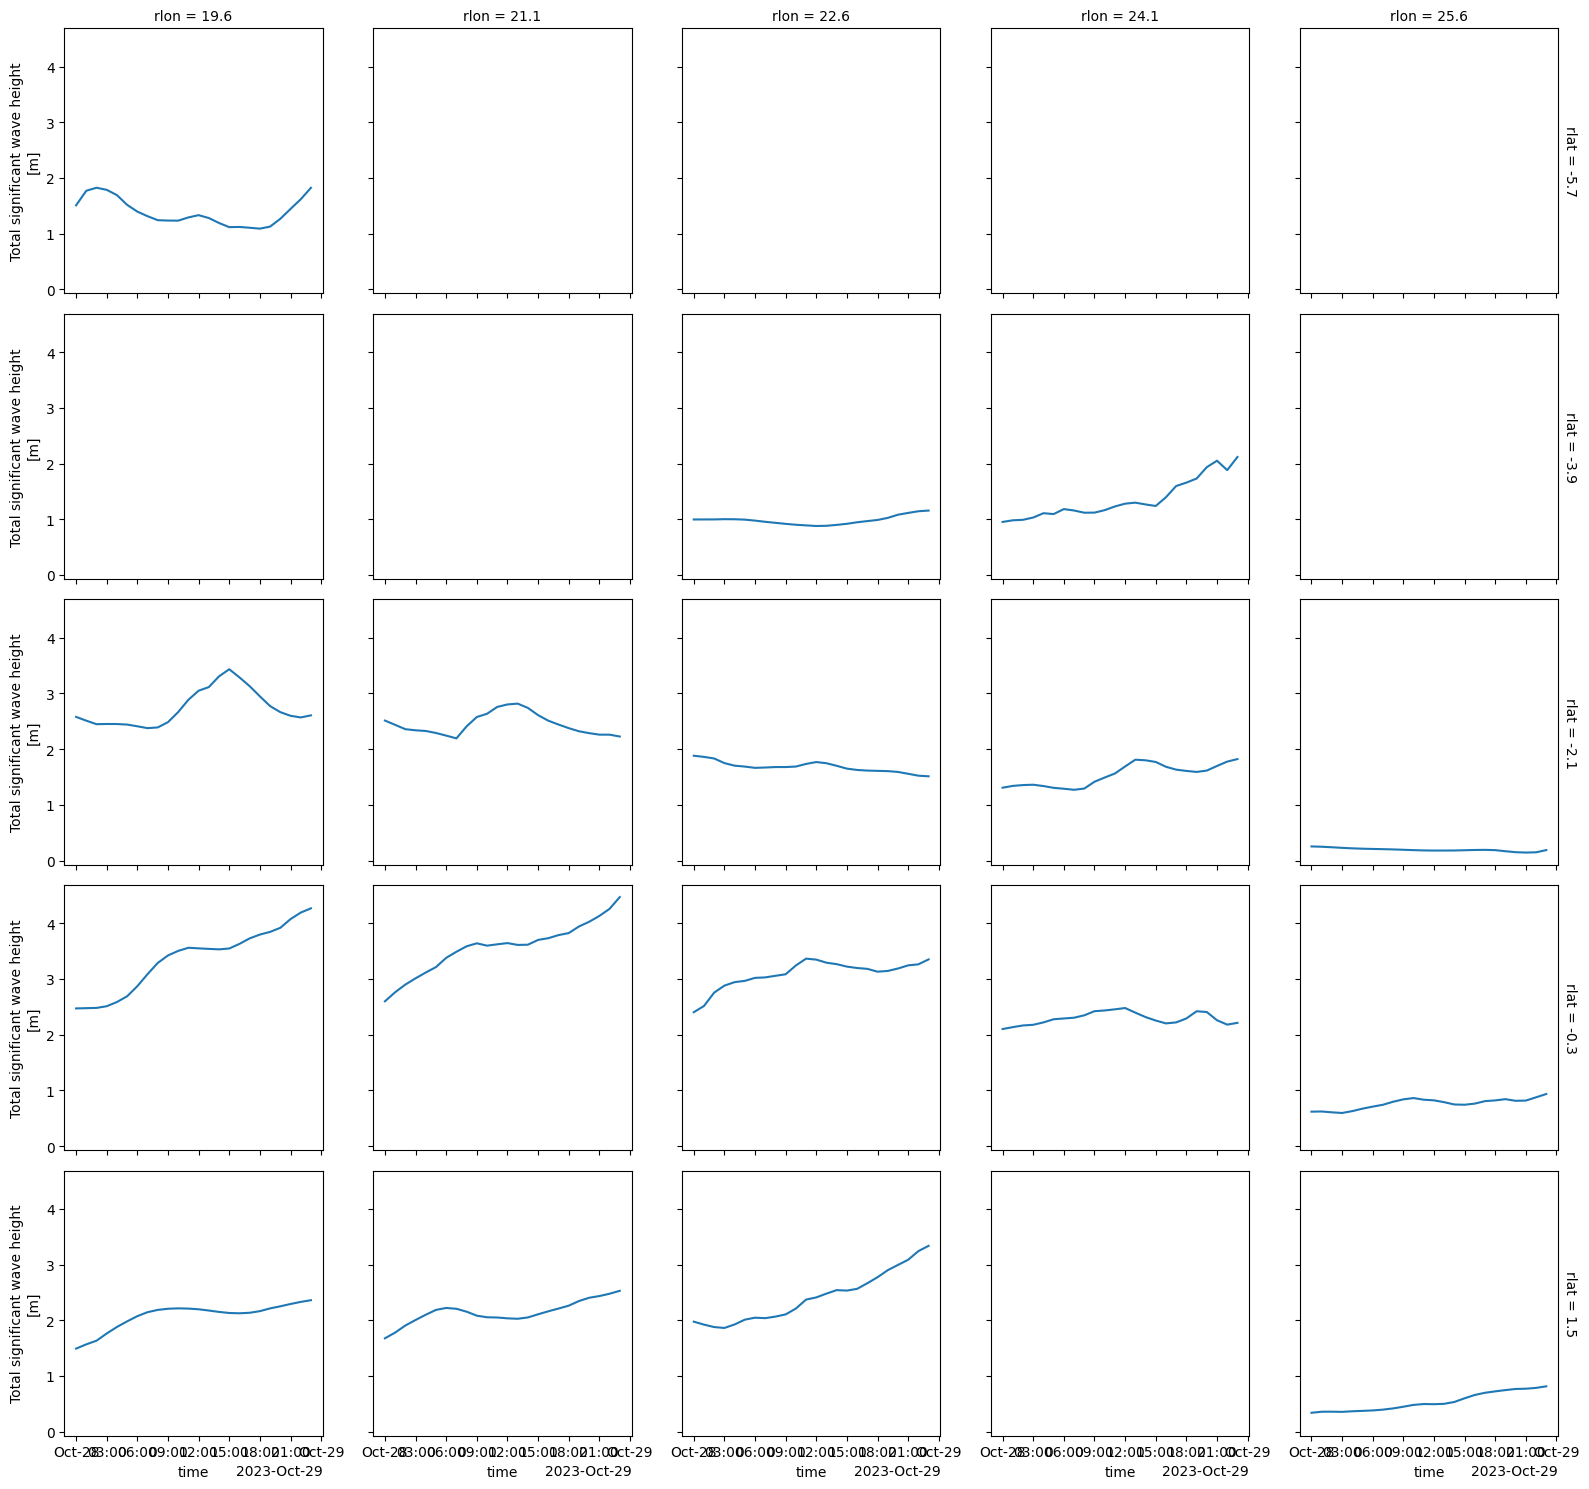

In [12]:
plt.figure()
hs.isel(
    rlon=slice(0, 250, 50),
    rlat=slice(0, 300, 60),
).plot(row="rlat", col="rlon")  # 5x5 faceted timeseries